# 06. Boosting Models

В предыдущих ноутбуках лучший результат дал простой ансамбль Ridge + Lasso.

На этом этапе проверим более сильные boosting-модели:

- XGBoost;
- LightGBM;
- CatBoost.

Цель ноутбука:

1. обучить boosting-модели в одинаковых условиях;
2. сравнить их по cross-validation;
3. создать submission-файлы;
4. проверить Kaggle Public Leaderboard score;
5. попробовать простой ансамбль boosting-моделей и линейного ансамбля;
6. выбрать лучшую финальную модель.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error
from sklearn.base import clone
from sklearn.linear_model import Ridge, Lasso

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [2]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

PROJECT_ROOT

PosixPath('/home/dany/ml_projects/house-price-regression')

In [3]:
from src.data import load_train_test
from src.features import prepare_features
from src.utils import (
    evaluate_model,
    create_submission,
    save_experiment_result,
)

In [4]:
train, test = load_train_test()

train.shape, test.shape

((1460, 81), (1459, 80))

In [5]:
X, y, X_test = prepare_features(train, test)

X.shape, y.shape, X_test.shape

((1460, 86), (1460,), (1459, 86))

In [6]:
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

len(numeric_features), len(categorical_features)

(43, 43)

## Preprocessing для boosting-моделей

Для boosting-моделей используем отдельный preprocessing:

- числовые признаки:
  - пропуски заполняются медианой;
  - масштабирование не используется;
- категориальные признаки:
  - пропуски заполняются самым частым значением;
  - категории кодируются через `OrdinalEncoder`.

Деревьям и бустингам не нужно масштабирование признаков.  
Также one-hot encoding может сильно увеличивать размерность, поэтому здесь используем ordinal encoding.

In [7]:
boosting_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

boosting_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "encoder",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

boosting_preprocessor = ColumnTransformer(
    transformers=[
        ("num", boosting_numeric_transformer, numeric_features),
        ("cat", boosting_categorical_transformer, categorical_features),
    ]
)

## Cross-validation setup

Используем тот же `KFold`, что и раньше:

- 5 folds;
- `shuffle=True`;
- `random_state=42`;
- метрика — RMSE по `log1p(SalePrice)`.


In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

## Boosting-модели

Проверим три популярные boosting-библиотеки:

- `XGBoost`;
- `LightGBM`;
- `CatBoost`.

Параметры выбраны как стартовые и не являются финальным tuning.

In [9]:
boosting_models = {
    "XGBoost": XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
    ),
    "LightGBM": LGBMRegressor(
        n_estimators=150,
        learning_rate=0.05,
        num_leaves=15,
        max_depth=4,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=1,
        verbose=-1,
    ),
    "CatBoost": CatBoostRegressor(
        iterations=1000,
        learning_rate=0.03,
        depth=6,
        loss_function="RMSE",
        random_seed=42,
        verbose=False,
        thread_count=1,
    ),
}

In [10]:
boosting_results = []

for model_name, model in boosting_models.items():
    print(f"Оценка модели: {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", boosting_preprocessor),
            ("model", model),
        ]
    )

    cv_rmse, cv_std, scores = evaluate_model(
        pipeline,
        X,
        y,
        cv,
    )

    boosting_results.append(
        {
            "Model": model_name,
            "CV RMSE": round(cv_rmse, 5),
            "CV std": round(cv_std, 5),
        }
    )

    print(f"CV RMSE: {cv_rmse:.5f}")
    print(f"CV std:  {cv_std:.5f}")
    print("-" * 50)

Оценка модели: XGBoost


CV RMSE: 0.12616
CV std:  0.01700
--------------------------------------------------
Оценка модели: LightGBM


/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages

CV RMSE: 0.13108
CV std:  0.01810
--------------------------------------------------
Оценка модели: CatBoost
CV RMSE: 0.12345
CV std:  0.01647
--------------------------------------------------


## Первичные результаты boosting-моделей

На этом этапе сравниваем модели по локальной cross-validation.

In [11]:
boosting_results_df = (
    pd.DataFrame(boosting_results)
    .sort_values("CV RMSE")
    .reset_index(drop=True)
)

boosting_results_df

,Model,CV RMSE,CV std
0,CatBoost,0.12345,0.01647
1,XGBoost,0.12616,0.01700
2,LightGBM,0.13108,0.01810


## Первичные выводы по boosting-моделям

По локальной cross-validation лучший результат показал `CatBoost`.

`XGBoost` также заметно улучшил локальный CV относительно предыдущих sklearn-моделей.

`LightGBM` в текущей стартовой конфигурации оказался слабее CatBoost и XGBoost, но остаётся перспективным кандидатом для отдельного tuning.

Важно: ранее в проекте уже было видно, что локальная CV и Kaggle Public Leaderboard могут расходиться. Поэтому окончательный вывод по boosting-моделям делаем только после отправки submission-файлов на Kaggle.

### Комментарий по LightGBM warning

Во время обучения LightGBM может появляться warning о feature names. Он связан с тем, что после `ColumnTransformer` модель получает numpy array без исходных имён колонок.

На текущем этапе это предупреждение не блокирует обучение и не мешает сравнению моделей.

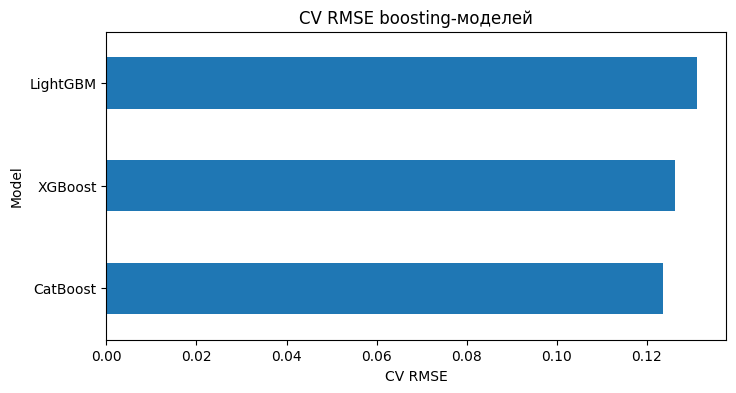

In [12]:
plt.figure(figsize=(8, 4))

(
    boosting_results_df
    .sort_values("CV RMSE")
    .plot(
        x="Model",
        y="CV RMSE",
        kind="barh",
        legend=False,
        ax=plt.gca(),
    )
)

plt.title("CV RMSE boosting-моделей")
plt.xlabel("CV RMSE")
plt.ylabel("Model")
plt.show()

In [13]:
results_path = PROJECT_ROOT / "reports" / "model_results.csv"

boosting_experiment_ids = {
    "XGBoost": "018",
    "LightGBM": "019",
    "CatBoost": "020",
}

boosting_kaggle_scores = {
    "018": 0.12784,  # XGBoost
    "019": np.nan,  # LightGBM не отправлялся отдельно
    "020": 0.12502,  # CatBoost
    "021": 0.12454,  # XGBoost + LightGBM + CatBoost ensemble
    "022": 0.12360,  # Linear ensemble + Boosting ensemble
}

In [14]:
results = None

for model_name, experiment_id in boosting_experiment_ids.items():
    row = boosting_results_df[
        boosting_results_df["Model"] == model_name
    ].iloc[0]

    results = save_experiment_result(
        results_path=results_path,
        experiment=experiment_id,
        model_name=model_name,
        cv_rmse=row["CV RMSE"],
        cv_std=row["CV std"],
        kaggle_score=boosting_kaggle_scores.get(experiment_id, np.nan),
        notes="boosting model with tree-specific preprocessing",
    )

results

,Experiment,Model,CV RMSE,CV std,Kaggle score,Notes
0,001,Ridge,0.14679,0.03932,0.13375,baseline
1,002,Ridge,0.11489,0.00818,0.13435,feature engineering + outlier removal
2,003,Ridge,0.14711,0.03976,0.13360,feature engineering without outlier removal
3,004,Ridge tuned,0.14700,0.03976,0.13262,feature engineering + tuned alpha without outl...
4,005,Ridge,0.14702,0.04052,0.13261,model comparison with feature engineering
5,006,Lasso,0.14171,0.04326,0.13277,model comparison with feature engineering
6,007,ElasticNet,0.14300,0.04132,0.13429,model comparison with feature engineering
7,008,RandomForestRegressor,0.14206,0.01889,0.14325,model comparison with feature engineering
8,009,HistGradientBoostingRegressor,0.13162,0.01786,NaN,model comparison with feature engineering
9,010,GradientBoostingRegressor,0.13224,0.01683,0.13680,model comparison with feature engineering


In [15]:
boosting_submission_filenames = {
    "XGBoost": "submission_018_xgboost.csv",
    "LightGBM": "submission_019_lightgbm.csv",
    "CatBoost": "submission_020_catboost.csv",
}

In [16]:
boosting_trained_pipelines = {}

for model_name, model in boosting_models.items():
    print(f"Обучение модели: {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", boosting_preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X, y)

    submission = create_submission(
        model=pipeline,
        X_test=X_test,
        test_ids=test["Id"],
        output_path=PROJECT_ROOT / "submissions" / boosting_submission_filenames[model_name],
    )

    boosting_trained_pipelines[model_name] = pipeline

    print(f"Submission сохранён: {boosting_submission_filenames[model_name]}")
    print("-" * 50)

Обучение модели: XGBoost
Submission сохранён: submission_018_xgboost.csv
--------------------------------------------------
Обучение модели: LightGBM
Submission сохранён: submission_019_lightgbm.csv
--------------------------------------------------
Обучение модели: CatBoost


/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Submission сохранён: submission_020_catboost.csv
--------------------------------------------------


## Ансамбль boosting-моделей

После того как созданы submission-файлы, можно сделать простой ансамбль

In [17]:
xgb_submission = pd.read_csv(PROJECT_ROOT / "submissions" / "submission_018_xgboost.csv")
lgbm_submission = pd.read_csv(PROJECT_ROOT / "submissions" / "submission_019_lightgbm.csv")
cat_submission = pd.read_csv(PROJECT_ROOT / "submissions" / "submission_020_catboost.csv")

boosting_ensemble_submission = xgb_submission.copy()
boosting_ensemble_submission["SalePrice"] = (
    xgb_submission["SalePrice"]
    + lgbm_submission["SalePrice"]
    + cat_submission["SalePrice"]
) / 3

boosting_ensemble_submission.head()

,Id,SalePrice
0,1461,123885.619679
1,1462,160827.626549
2,1463,183081.824088
3,1464,192351.605257
4,1465,185679.786480


In [18]:
boosting_ensemble_path = PROJECT_ROOT / "submissions" / "submission_021_boosting_ensemble.csv"

boosting_ensemble_submission.to_csv(boosting_ensemble_path, index=False)

boosting_ensemble_path

PosixPath('/home/dany/ml_projects/house-price-regression/submissions/submission_021_boosting_ensemble.csv')

In [19]:
linear_ensemble_submission = pd.read_csv(
    PROJECT_ROOT
    / "submissions"
    / "submission_017_ridge_lasso_ensemble.csv"
)

mixed_ensemble_submission = linear_ensemble_submission.copy()

mixed_ensemble_submission["SalePrice"] = (
    0.5 * linear_ensemble_submission["SalePrice"]
    + 0.5 * boosting_ensemble_submission["SalePrice"]
)

mixed_ensemble_submission.head()

,Id,SalePrice
0,1461,119955.542509
1,1462,154038.349755
2,1463,177472.845124
3,1464,194542.636395
4,1465,190148.445625


In [20]:
mixed_ensemble_path = (
    PROJECT_ROOT
    / "submissions"
    / "submission_022_linear_boosting_ensemble.csv"
)

mixed_ensemble_submission.to_csv(
    mixed_ensemble_path,
    index=False,
)

mixed_ensemble_path

PosixPath('/home/dany/ml_projects/house-price-regression/submissions/submission_022_linear_boosting_ensemble.csv')

## OOF-оценка ансамблей

Лучший Kaggle score на этом этапе дал смешанный ансамбль `Linear ensemble + Boosting ensemble`.

Чтобы не выбирать лучшую модель только по Public Leaderboard, добавим локальную OOF-оценку для ансамблей.

Здесь мы считаем OOF-предсказания в том же стиле, что и submission:

- модели обучаются на `log1p(SalePrice)`;
- предсказания переводятся обратно в цену через `expm1`;
- ансамбли усредняются в исходном масштабе цены;
- итоговая ошибка считается в log-space через `log1p`.

Этот блок может выполняться дольше обычных ячеек, потому что повторно обучает несколько моделей на folds.

In [21]:
# Linear ensemble OOF: Ridge + Lasso
linear_numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

linear_categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", linear_numeric_transformer, numeric_features),
        ("cat", linear_categorical_transformer, categorical_features),
    ],
    sparse_threshold=0,
)

ridge_pipeline = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Ridge(alpha=20)),
    ]
)

lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("model", Lasso(alpha=0.0005, max_iter=50000, random_state=42)),
    ]
)

ridge_oof_log = cross_val_predict(
    ridge_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1,
)

lasso_oof_log = cross_val_predict(
    lasso_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=-1,
)

linear_oof_price = (
    0.5 * np.expm1(ridge_oof_log)
    + 0.5 * np.expm1(lasso_oof_log)
)
linear_oof_log = np.log1p(linear_oof_price)

linear_ensemble_oof_rmse = root_mean_squared_error(
    y,
    linear_oof_log,
)

print(f"OOF RMSE linear ensemble: {linear_ensemble_oof_rmse:.5f}")

OOF RMSE linear ensemble: 0.14922


In [22]:
# Boosting ensemble OOF: XGBoost + LightGBM + CatBoost
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        ("model", boosting_models["XGBoost"]),
    ]
)

lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        ("model", boosting_models["LightGBM"]),
    ]
)

cat_pipeline = Pipeline(
    steps=[
        ("preprocessor", boosting_preprocessor),
        ("model", boosting_models["CatBoost"]),
    ]
)

xgb_oof_log = cross_val_predict(
    xgb_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=1,
)

lgbm_oof_log = cross_val_predict(
    lgbm_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=1,
)

cat_oof_log = cross_val_predict(
    cat_pipeline,
    X,
    y,
    cv=cv,
    n_jobs=1,
)

boosting_oof_price = (
    np.expm1(xgb_oof_log)
    + np.expm1(lgbm_oof_log)
    + np.expm1(cat_oof_log)
) / 3

boosting_oof_log = np.log1p(boosting_oof_price)

boosting_ensemble_oof_rmse = root_mean_squared_error(
    y,
    boosting_oof_log,
)

print(f"OOF RMSE boosting ensemble: {boosting_ensemble_oof_rmse:.5f}")

/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/home/dany/ml_projects/house-price-regression/.venv/lib/python3.10/site-packages

OOF RMSE boosting ensemble: 0.12530


In [23]:
# Mixed ensemble OOF: 0.5 linear ensemble + 0.5 boosting ensemble
mixed_oof_price = (
    0.5 * linear_oof_price
    + 0.5 * boosting_oof_price
)

mixed_oof_log = np.log1p(mixed_oof_price)

mixed_ensemble_oof_rmse = root_mean_squared_error(
    y,
    mixed_oof_log,
)

print(f"OOF RMSE mixed ensemble: {mixed_ensemble_oof_rmse:.5f}")

OOF RMSE mixed ensemble: 0.13535


In [24]:
results = save_experiment_result(
    results_path=results_path,
    experiment="021",
    model_name="XGBoost + LightGBM + CatBoost ensemble",
    cv_rmse=round(boosting_ensemble_oof_rmse, 5),
    cv_std=np.nan,
    kaggle_score=boosting_kaggle_scores.get("021", np.nan),
    notes="average of XGBoost, LightGBM and CatBoost submissions",
)

results = save_experiment_result(
    results_path=results_path,
    experiment="022",
    model_name="Linear ensemble + Boosting ensemble",
    cv_rmse=round(mixed_ensemble_oof_rmse, 5),
    cv_std=np.nan,
    kaggle_score=boosting_kaggle_scores.get("022", np.nan),
    notes="0.5 linear ensemble + 0.5 boosting ensemble",
)

results

,Experiment,Model,CV RMSE,CV std,Kaggle score,Notes
0,001,Ridge,0.14679,0.03932,0.13375,baseline
1,002,Ridge,0.11489,0.00818,0.13435,feature engineering + outlier removal
2,003,Ridge,0.14711,0.03976,0.13360,feature engineering without outlier removal
3,004,Ridge tuned,0.14700,0.03976,0.13262,feature engineering + tuned alpha without outl...
4,005,Ridge,0.14702,0.04052,0.13261,model comparison with feature engineering
5,006,Lasso,0.14171,0.04326,0.13277,model comparison with feature engineering
6,007,ElasticNet,0.14300,0.04132,0.13429,model comparison with feature engineering
7,008,RandomForestRegressor,0.14206,0.01889,0.14325,model comparison with feature engineering
8,009,HistGradientBoostingRegressor,0.13162,0.01786,NaN,model comparison with feature engineering
9,010,GradientBoostingRegressor,0.13224,0.01683,0.13680,model comparison with feature engineering


## Сравнение CV и Kaggle Public Leaderboard

Сравним локальную CV/OOF-оценку и Kaggle Public Leaderboard score.

Важно помнить, что Public Leaderboard считается только на части test-выборки, поэтому лучший Kaggle score не является абсолютной гарантией лучшей обобщающей способности.

In [25]:
boosting_comparison = pd.DataFrame(
    [
        {
            "Model": "XGBoost",
            "CV / OOF RMSE": boosting_results_df.loc[
                boosting_results_df["Model"] == "XGBoost",
                "CV RMSE",
            ].iloc[0],
            "Kaggle score": boosting_kaggle_scores["018"],
        },
        {
            "Model": "LightGBM",
            "CV / OOF RMSE": boosting_results_df.loc[
                boosting_results_df["Model"] == "LightGBM",
                "CV RMSE",
            ].iloc[0],
            "Kaggle score": boosting_kaggle_scores["019"],
        },
        {
            "Model": "CatBoost",
            "CV / OOF RMSE": boosting_results_df.loc[
                boosting_results_df["Model"] == "CatBoost",
                "CV RMSE",
            ].iloc[0],
            "Kaggle score": boosting_kaggle_scores["020"],
        },
        {
            "Model": "Boosting ensemble",
            "CV / OOF RMSE": round(boosting_ensemble_oof_rmse, 5),
            "Kaggle score": boosting_kaggle_scores["021"],
        },
        {
            "Model": "Linear + Boosting ensemble",
            "CV / OOF RMSE": round(mixed_ensemble_oof_rmse, 5),
            "Kaggle score": boosting_kaggle_scores["022"],
        },
    ]
)

boosting_comparison

,Model,CV / OOF RMSE,Kaggle score
0,XGBoost,0.12616,0.12784
1,LightGBM,0.13108,NaN
2,CatBoost,0.12345,0.12502
3,Boosting ensemble,0.12530,0.12454
4,Linear + Boosting ensemble,0.13535,0.12360


## Итоги boosting-экспериментов

На этом этапе были проверены:

- XGBoost;
- LightGBM;
- CatBoost;
- boosting ensemble;
- mixed linear + boosting ensemble.

### Основные результаты

| Experiment | Model | CV / OOF RMSE | Kaggle score |
|---|---|---:|---:|
| 018 | XGBoost | 0.12616 | 0.12784 |
| 019 | LightGBM | 0.13108 | - |
| 020 | CatBoost | 0.12345 | 0.12502 |
| 021 | XGBoost + LightGBM + CatBoost ensemble | 0.12530 | 0.12454 |
| 022 | Linear ensemble + Boosting ensemble | 0.13535 | 0.12360 |

### Главный вывод

CatBoost оказался сильнейшей отдельной boosting-моделью по локальной CV и Kaggle score среди отправленных boosting-моделей.

Boosting ensemble улучшил Kaggle score относительно отдельных boosting-моделей.

Mixed ensemble дал лучший Public Leaderboard score: `0.12360`.

### Важная оговорка

Mixed ensemble имеет лучший Kaggle score, но не лучший OOF RMSE.

Его нельзя считать гарантированно лучшей моделью по обобщающей способности. Скорее, это лучший Public Leaderboard submission на текущем этапе.

Для финального выбора модели нужно дополнительно:

- проверить несколько CV-разбиений;
- подобрать веса ансамбля по OOF;
- сравнить OOF, CV и Kaggle вместе.

### Следующий шаг

Следующий этап проекта — финализация:

- выбрать финальный pipeline;
- сделать `src/train.py`;
- сохранить модель или ансамбль;
- описать воспроизводимый запуск в README.